In [4]:
import h5py
import numpy as np
import xarray as xr
# import matplotlib.pyplot as plt  <-- REMOVED TO PREVENT CRASH

# --- Configuration ---
PR = 0
DAYS = 10
STEPS_PER_DAY = 4  # 6-hourly data
N_STEPS = DAYS * STEPS_PER_DAY  # 40 steps

# File Paths
base_dir = f"/data92/PeterChang/Dycore_data/PR{PR}"
files = {
    'u': f"{base_dir}/u/PR{PR}_500_20000day_u_6hourly.h5",
    'v': f"{base_dir}/v/PR{PR}_500_20000day_v_6hourly.h5",
    't': f"{base_dir}/t/PR{PR}_500_20000day_t_6hourly.h5",
    'ps': f"{base_dir}/ps/PR{PR}_500_20000day_ps_6hourly.h5"
}

# --- 1. Load First 40 Steps Directly ---
print(f"Loading first {DAYS} days ({N_STEPS} steps) into memory...")

data_arrays = {}
for var, path in files.items():
    with h5py.File(path, 'r') as f:
        key = list(f.keys())[0]
        # Slice [0:40] immediately
        data_arrays[var] = f[key][:N_STEPS]

# Handle PS shape (ensure it is [time, lat, lon])
ps_data = data_arrays['ps']
if ps_data.ndim == 4:
    ps_data = ps_data[:, 0, :, :]
elif ps_data.ndim == 2: 
    # Handle rare edge case
    raise ValueError("Check PS dimensions")

# --- 2. Create Xarray Dataset ---
# Coordinates
lat = np.linspace(-90, 90, 64)
lon = np.linspace(0, 360, 128, endpoint=False)
time = np.arange(N_STEPS) * 0.25 # time in days

# --- CRITICAL FIX: SIGMA ORDERING ---
# Since index 19 is the surface (1.0) and index 0 is top (0.05),
# the array must increase from 0.05 to 1.0.
sigma = np.linspace(0.05, 1.0, 20) 

ds = xr.Dataset(
    data_vars={
        'u': (('time', 'sigma', 'lat', 'lon'), data_arrays['u']),
        'v': (('time', 'sigma', 'lat', 'lon'), data_arrays['v']),
        't': (('time', 'sigma', 'lat', 'lon'), data_arrays['t']),
        'ps': (('time', 'lat', 'lon'), ps_data),
    },
    coords={'time': time, 'sigma': sigma, 'lat': lat, 'lon': lon}
)

# --- 3. Calculation Function ---
def calculate_ep_flux_simple(ds):
    # Constants
    a = 6.371e6; R = 287.0; cp = 1004.0; kappa = R/cp
    Omega = 7.2921e-5; P0 = 100000.0; H = 7000.0
    
    # Geometry
    lat_rad = np.deg2rad(ds.lat)
    cos_lat = np.cos(lat_rad)
    f = 2 * Omega * np.sin(lat_rad)
    
    # Interpolation Grid (REVISED FOR PA)
    # Define targets directly in Pascals. 
    target_plevs_pa = np.array([1000, 925, 850, 700, 600, 500, 400, 
                                300, 250, 200, 150, 100, 70, 50]) * 100.0
    
    plev_da = xr.DataArray(target_plevs_pa, dims='plev', coords={'plev': target_plevs_pa})
    
    # 4D Interpolation coordinates
    # Since ds.ps is in Pa and plev_da is in Pa, the ratio is correct (unitless)
    target_sigma = plev_da / ds.ps
    
    print("Interpolating (Sigma -> Pressure)...")
    # This interpolation now works correctly because ds.sigma matches the data order
    ds_iso = ds[['u', 'v', 't']].interp(sigma=target_sigma, method='linear')
    ds_iso['theta'] = ds_iso.t * (P0 / plev_da)**kappa

    print("Calculating Fluxes...")
    # Zonal Means
    u_bar = ds_iso.u.mean(dim='lon')
    v_bar = ds_iso.v.mean(dim='lon')
    th_bar = ds_iso.theta.mean(dim='lon')
    
    # Eddies
    uv_eddy = ((ds_iso.u - u_bar) * (ds_iso.v - v_bar)).mean(dim='lon')
    vth_eddy = ((ds_iso.v - v_bar) * (ds_iso.theta - th_bar)).mean(dim='lon')
    
    # Stability dTheta/dz
    # Note: plev_da is in Pa. 
    # The derivative .differentiate('plev') will be per Pa.
    dth_dp = th_bar.differentiate('plev')
    
    # d/dz = -(p/H) * d/dp
    # p is in Pa, H is in meters. Formula holds regardless of pressure units 
    # as long as p and dp cancel out or are consistent.
    dth_dz = -(plev_da / H) * dth_dp
    
    # Avoid zero division
    dth_dz = dth_dz.where(np.abs(dth_dz) > 1e-4)

    # Flux Vectors
    F_phi = -1 * a * cos_lat * uv_eddy
    F_z = a * cos_lat * f * (vth_eddy / dth_dz)
    
    # Divergence
    F_phi_cos = F_phi * cos_lat
    term_phi = (1.0 / (a * cos_lat)) * F_phi_cos.differentiate('lat') * (180.0 / np.pi)
    
    dFz_dp = F_z.differentiate('plev')
    dFz_dz = -(plev_da / H) * dFz_dp
    term_z = dFz_dz - (F_z / H)
    
    div_F = (term_phi + term_z) * 86400.0 # m/s/day
    
    return xr.Dataset({
        'F_phi': F_phi, 'F_z': F_z, 'div_F': div_F, 'u_bar': u_bar
    })

# --- 4. Run and Save ---
result = calculate_ep_flux_simple(ds)

# Take the time mean for cleaner output
result_mean = result.mean(dim='time')

output_file = "ep_flux_first_10_days.nc"
print(f"Calculation Done. Saving to '{output_file}'...")
result_mean.to_netcdf(output_file)
print("Success! File saved.")

Loading first 10 days (40 steps) into memory...
Interpolating (Sigma -> Pressure)...
Calculating Fluxes...
Calculation Done. Saving to 'ep_flux_first_10_days.nc'...
Success! File saved.


Reading ep_flux_first_10_days.nc...
DIAGNOSTICS (Corrected):
  Acceleration Max: 216.51 m/s/day
  Acceleration Min: -168.37 m/s/day


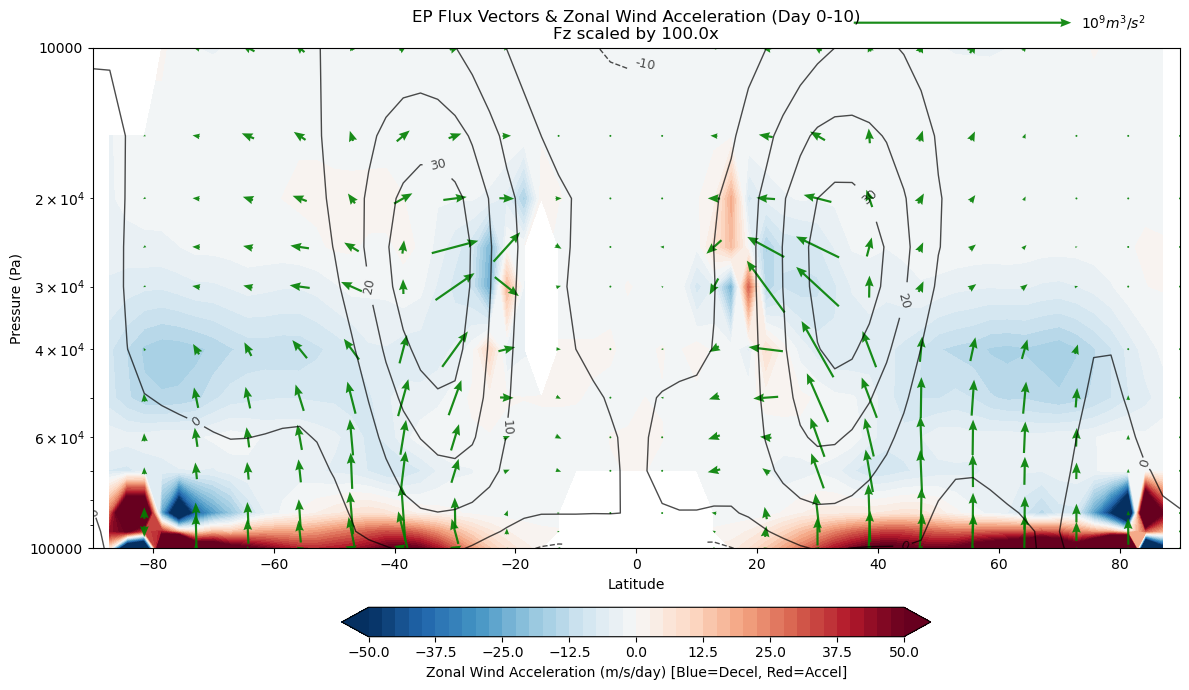

In [5]:
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np

# --- 1. Physical Constants ---
a = 6.371e6  # Earth Radius in meters

def plot_ep_flux_results(filename):
    print(f"Reading {filename}...")
    try:
        ds = xr.open_dataset(filename)
    except FileNotFoundError:
        print("File not found. Please run the calculation script first.")
        return

    # --- 2. Fix Dimensions ---
    # Matplotlib expects (Pressure, Lat), but xarray often saves as (Lat, Pressure).
    # This ensures the order is correct.
    ds = ds.transpose('plev', 'lat') 
    
    # --- 3. PHYSICS CORRECTION: Convert Torque to Acceleration ---
    # The calculated 'div_F' is the divergence of Angular Momentum Flux (Torque).
    # To get Zonal Wind Acceleration (m/s/day), we must divide by the moment arm (a * cos(phi)).
    
    lat_rad = np.deg2rad(ds.lat)
    cos_lat = np.cos(lat_rad)
    
    # Avoid division by zero at poles by masking very small cosines
    cos_lat = cos_lat.where(np.abs(cos_lat) > 1e-2)
    
    # Calculate Acceleration: Units become (m/s/day)
    # The 'div_F' input was already scaled to 'per day' in the calculation script.
    accel = ds.div_F / (a * cos_lat)

    # --- 4. Diagnostics ---
    max_acc = np.nanmax(accel.values)
    min_acc = np.nanmin(accel.values)
    print(f"DIAGNOSTICS (Corrected):")
    print(f"  Acceleration Max: {max_acc:.2f} m/s/day")
    print(f"  Acceleration Min: {min_acc:.2f} m/s/day")

    # --- 5. Vector Scaling ---
    # Vertical flux (Fz) is physically much smaller than Fphi. 
    # We multiply Fz by 300 so vertical wave propagation is visible to the eye.
    F_Z_SCALE = 100.0
    F_z_scaled = ds.F_z * F_Z_SCALE

    # --- 6. Plotting Setup ---
    fig, ax = plt.subplots(figsize=(12, 7))

    # A. Contour Filled: Zonal Wind Acceleration
    # Range: +/- 50 m/s/day is appropriate for "Day 0-10" model spin-up shocks.
    # (For smooth climatology, you would use limits of +/- 10).
    limit = 50 
    levels = np.linspace(-limit, limit, 41) 
    
    cf = ax.contourf(ds.lat, ds.plev, accel, 
                     levels=levels, 
                     cmap='RdBu_r', 
                     extend='both') # 'both' captures values exceeding +/- 50
    
    cbar = plt.colorbar(cf, ax=ax, orientation='horizontal', pad=0.1, fraction=0.05)
    cbar.set_label('Zonal Wind Acceleration (m/s/day) [Blue=Decel, Red=Accel]')

    # B. Contour Lines: Zonal Mean Wind (u_bar)
    # This shows the location of the Jet Stream.
    clevs_u = np.arange(-40, 100, 10)
    cs = ax.contour(ds.lat, ds.plev, ds.u_bar, 
                    levels=clevs_u, 
                    colors='black', 
                    linewidths=1.0,
                    alpha=0.7)
    ax.clabel(cs, fmt='%d', fontsize=9)

    # C. Quiver: EP Flux Vectors
    # Subsample (skip) points to prevent overcrowding
    skip_lat = 3 
    skip_lev = 1
    
    lat_sub = ds.lat[::skip_lat]
    lev_sub = ds.plev[::skip_lev]
    F_phi_sub = ds.F_phi[::skip_lev, ::skip_lat]
    F_z_sub = F_z_scaled[::skip_lev, ::skip_lat]

    # Vector Scale: 
    # 5e9 is a good visual scale for 10^8 - 10^9 magnitude fluxes.
    vector_scale = 5e9 
    
    Q = ax.quiver(lat_sub, lev_sub, F_phi_sub, F_z_sub,
                  color='green',
                  alpha=0.9,
                  width=0.002,
                  headwidth=4,
                  scale=vector_scale, 
                  pivot='mid')

    # Reference Key
    ax.quiverkey(Q, 0.9, 1.05, 1e9, r'$10^9 m^3/s^2$', labelpos='E', coordinates='axes')

    # D. Axis Formatting
    ax.set_yscale('log')
    ax.set_ylim(100000, 10000) # Surface (1000hPa) to Stratosphere (100hPa)
    # ax.invert_yaxis()         
    ax.yaxis.set_major_formatter(ticker.ScalarFormatter())
    
    ax.set_title(f'EP Flux Vectors & Zonal Wind Acceleration (Day 0-10)\nFz scaled by {F_Z_SCALE}x')
    ax.set_xlabel('Latitude')
    ax.set_ylabel('Pressure (Pa)')
    
    plt.tight_layout()
    plt.show()

# --- Execution ---
if __name__ == "__main__":
    plot_ep_flux_results("ep_flux_first_10_days.nc")

Reading ep_flux_first_10_days.nc...
<xarray.DataArray ()> Size: 8B
array(-168.37453281) <xarray.DataArray ()> Size: 8B
array(216.50700067)


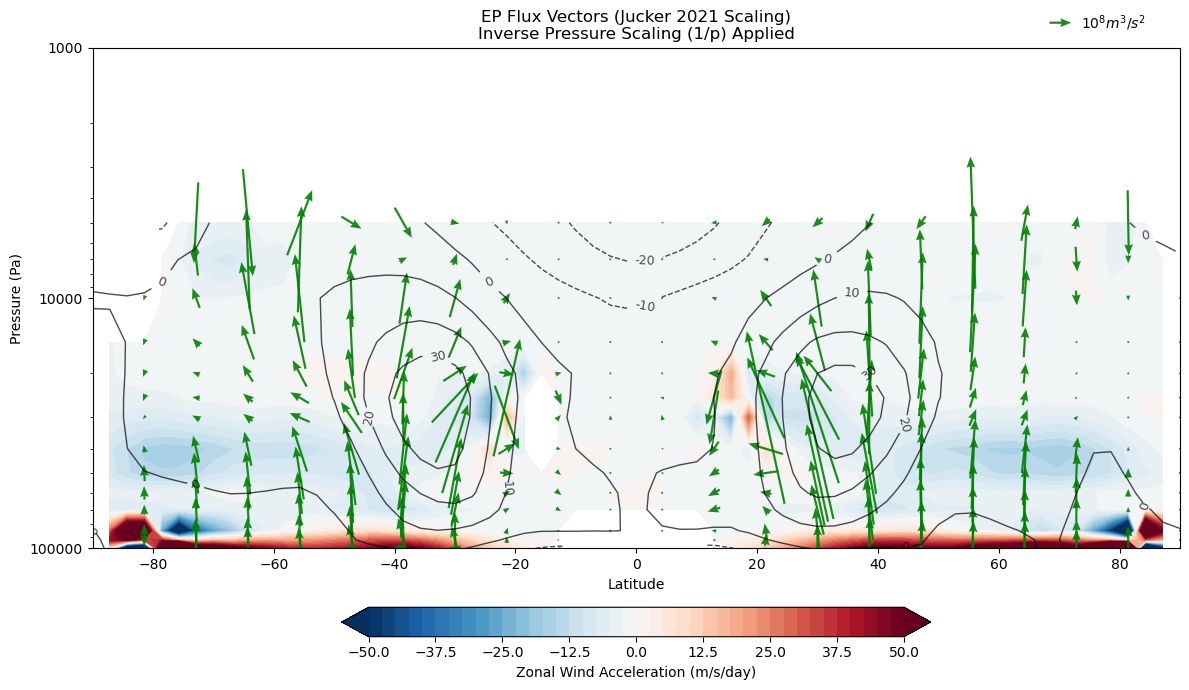

In [16]:
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np

# --- 1. Physical Constants ---
a = 6.371e6  # Earth Radius in meters

def plot_ep_flux_results(filename):
    print(f"Reading {filename}...")
    try:
        ds = xr.open_dataset(filename)
    except FileNotFoundError:
        print("File not found. Please run the calculation script first.")
        return

    # --- 2. Fix Dimensions ---
    ds = ds.transpose('plev', 'lat') 
    
    # --- 3. PHYSICS CORRECTION: Convert Torque to Acceleration ---
    # Accel = div_F / (a * cos(lat))
    lat_rad = np.deg2rad(ds.lat)
    cos_lat = np.cos(lat_rad)
    cos_lat = cos_lat.where(np.abs(cos_lat) > 1e-2)
    accel = ds.div_F / (a * cos_lat)

    # --- 4. JUCKER (2021) SCALING ---
    # Reference: Jucker, M. (2021). Scaling of Eliassen-Palm Flux Vectors.
    # The vertical component must be scaled by 1/p to account for the log-pressure axis.
    # We also need an 'aspect ratio' factor to make the arrows point in the correct visual direction.
    
    # A. Calculate Plot Aspect Ratio (approximate)
    # We assume a standard Matplotlib figure size (e.g., ratio of ~0.6 height/width)
    # or we can calculate it from the data ranges.
    
    # Range of x-axis (Latitude in degrees)
    x_range = ds.lat.max() - ds.lat.min() # ~180
    
    # Range of y-axis (Log Pressure)
    # We use log10 for the "visual" height of the axis
    y_range = np.log10(ds.plev.max()) - np.log10(ds.plev.min()) # log10(100000) - log10(10000) = 1
    
    # Visual Aspect Ratio of the Axes box (Height / Width in pixels)
    # Standard matplotlib plots are roughly 0.6 to 0.7 aspect ratio
    visual_aspect = 0.6 
    
    # B. The Scaling Factor (C)
    # Fz_scaled = Fz * (1/p) * C
    # C ensures the units match the visual dimensions.
    # Formula: C = (x_range / y_range) * visual_aspect * (units_conversion)
    
    # Simplified Jucker Factor:
    # We normalize pressure by Surface Pressure (100000 Pa) to keep the factor dimensionless 
    # and then apply a base magnitude scaler.
    p_norm = ds.plev / 100000.0
    
    # Inverse Pressure Scaling (1/p)
    # This makes vectors at 10hPa (top) 100x larger than at surface, naturally.
    # We multiply by ~100 to ~200 to match the previous visual baseline at the surface.
    JUCKER_CONSTANT = 100.0 
    
    # Apply Scaling
    F_z_scaled = ds.F_z * (1.0 / p_norm) * JUCKER_CONSTANT

    # --- 5. Plotting Setup ---
    fig, ax = plt.subplots(figsize=(12, 7))

    # A. Contour Filled: Zonal Wind Acceleration
    limit = 50 
    levels = np.linspace(-limit, limit, 41) 
    print(np.min(accel), np.max(accel))
    cf = ax.contourf(ds.lat, ds.plev, accel, 
                     levels=levels, 
                     cmap='RdBu_r', 
                     extend='both')
    
    cbar = plt.colorbar(cf, ax=ax, orientation='horizontal', pad=0.1, fraction=0.05)
    cbar.set_label('Zonal Wind Acceleration (m/s/day)')

    # B. Contour Lines: Zonal Mean Wind
    clevs_u = np.arange(-40, 100, 10)
    cs = ax.contour(ds.lat, ds.plev, ds.u_bar, 
                    levels=clevs_u, 
                    colors='black', 
                    linewidths=1.0,
                    alpha=0.7)
    ax.clabel(cs, fmt='%d', fontsize=9)

    # C. Quiver: EP Flux Vectors
    skip_lat = 3 
    skip_lev = 1
    
    lat_sub = ds.lat[::skip_lat]
    lev_sub = ds.plev[::skip_lev]
    F_phi_sub = ds.F_phi[::skip_lev, ::skip_lat]
    
    # USE JUCKER SCALED VERTICAL FLUX
    F_z_sub = F_z_scaled[::skip_lev, ::skip_lat]

    # Vector Scale
    # Note: Since we scaled Fz up by 1/p, the overall vector magnitudes in the stratosphere 
    # are much larger. We might need to adjust the quiver scale slightly.
    vector_scale = 5e9 
    
    Q = ax.quiver(lat_sub, lev_sub, F_phi_sub, F_z_sub,
                  color='green',
                  alpha=0.9,
                  width=0.002,
                  headwidth=4,
                  scale=vector_scale, 
                  pivot='mid')

    ax.quiverkey(Q, 0.9, 1.05, 1e8, r'$10^8 m^3/s^2$', labelpos='E', coordinates='axes')

    # D. Formatting
    ax.set_yscale('log')
    ax.set_ylim(100000, 1000) # Plot up to 10 hPa to see stratospheric arrows
    # ax.invert_yaxis()         
    ax.yaxis.set_major_formatter(ticker.ScalarFormatter())
    
    ax.set_title(f'EP Flux Vectors (Jucker 2021 Scaling)\nInverse Pressure Scaling (1/p) Applied')
    ax.set_xlabel('Latitude')
    ax.set_ylabel('Pressure (Pa)')
    
    plt.tight_layout()
    plt.show()

# --- Execution ---
if __name__ == "__main__":
    plot_ep_flux_results("ep_flux_first_10_days.nc")

# Batch calculation

In [53]:
import h5py
import numpy as np
import xarray as xr
from tqdm import tqdm
from contextlib import ExitStack

# --- Configuration ---
PR = 0
TOTAL_DAYS = 19500      
STEPS_PER_DAY = 4       # 6-hourly data
N_STEPS = TOTAL_DAYS * STEPS_PER_DAY

# OPTIMIZATION: Reduce batch size to 5 days to see progress updates
BATCH_DAYS = 5          
BATCH_STEPS = BATCH_DAYS * STEPS_PER_DAY

output_file = f"ep_flux_climatology_PR{PR}_{TOTAL_DAYS}days.nc"

base_dir = f"/data92/PeterChang/Dycore_data/PR{PR}"
file_paths = {
    'u': f"{base_dir}/u/PR{PR}_500_20000day_u_6hourly.h5",
    'v': f"{base_dir}/v/PR{PR}_500_20000day_v_6hourly.h5",
    't': f"{base_dir}/t/PR{PR}_500_20000day_t_6hourly.h5",
    'ps': f"{base_dir}/ps/PR{PR}_500_20000day_ps_6hourly.h5"
}

# --- Shared Coordinates ---
lat = np.linspace(-90, 90, 64)
lon = np.linspace(0, 360, 128, endpoint=False)
sigma = np.linspace(0.05, 1.0, 20) 
target_plevs_pa = np.array([1000, 925, 850, 700, 600, 500, 400, 
                            300, 250, 200, 150, 100, 70, 50]) * 100.0

# --- Worker Function ---
def process_batch(start_idx, end_idx, open_files):
    
    # 1. Load Data Slice (Fast I/O)
    data_arrays = {}
    batch_time = np.arange(start_idx, end_idx) * 0.25 

    for var, f_handle in open_files.items():
        key = list(f_handle.keys())[0]
        data = f_handle[key][start_idx:end_idx]
        if var == 'ps' and data.ndim == 4:
            data = data[:, 0, :, :]
        data_arrays[var] = data

    ds = xr.Dataset(
        data_vars={
            'u': (('time', 'sigma', 'lat', 'lon'), data_arrays['u']),
            'v': (('time', 'sigma', 'lat', 'lon'), data_arrays['v']),
            't': (('time', 'sigma', 'lat', 'lon'), data_arrays['t']),
            'ps': (('time', 'lat', 'lon'), data_arrays['ps']),
        },
        coords={'time': batch_time, 'sigma': sigma, 'lat': lat, 'lon': lon}
    )

    # 2. Calculation setup
    a = 6.371e6; R = 287.0; cp = 1004.0; kappa = R/cp
    Omega = 7.2921e-5; P0 = 100000.0; H = 7000.0
    
    lat_rad = np.deg2rad(ds.lat)
    cos_lat = np.cos(lat_rad)
    f_cor = 2 * Omega * np.sin(lat_rad)
    
    plev_da = xr.DataArray(target_plevs_pa, dims='plev', coords={'plev': target_plevs_pa})

    # --- CRITICAL FIX: Loop over time for Interpolation ---
    # Interpolating a 4D chunk at once is too slow. We do it step-by-step.
    iso_list = []
    
    for t_idx in range(ds.sizes['time']):
        # Select single time step
        ds_step = ds.isel(time=t_idx)
        
        # Calculate target sigma for this step (plev, lat, lon)
        target_sigma_step = plev_da / ds_step.ps
        
        # Interpolate this step only (Much faster!)
        # We perform interpolation on u, v, t simultaneously
        iso_step = ds_step[['u', 'v', 't']].interp(sigma=target_sigma_step, method='linear')
        
        iso_list.append(iso_step)

    # Recombine back into a batch dataset
    ds_iso = xr.concat(iso_list, dim='time')
    
    # --- Continue Calculations ---
    ds_iso['theta'] = ds_iso.t * (P0 / plev_da)**kappa

    # Means & Eddies
    u_bar = ds_iso.u.mean(dim='lon')
    v_bar = ds_iso.v.mean(dim='lon')
    th_bar = ds_iso.theta.mean(dim='lon')
    
    uv_eddy = ((ds_iso.u - u_bar) * (ds_iso.v - v_bar)).mean(dim='lon')
    vth_eddy = ((ds_iso.v - v_bar) * (ds_iso.theta - th_bar)).mean(dim='lon')

    # Stability
    dth_dp = th_bar.differentiate('plev')
    dth_dz = -(plev_da / H) * dth_dp
    dth_dz = dth_dz.where(np.abs(dth_dz) > 1e-4)

    # Fluxes
    F_phi = -1 * a * cos_lat * uv_eddy
    F_z = a * cos_lat * f_cor * (vth_eddy / dth_dz)

    # Divergence
    F_phi_cos = F_phi * cos_lat
    term_phi = (1.0 / (a * cos_lat)) * F_phi_cos.differentiate('lat') * (180.0 / np.pi)
    
    dFz_dp = F_z.differentiate('plev')
    dFz_dz = -(plev_da / H) * dFz_dp
    term_z = dFz_dz - (F_z / H)
    
    div_F = (term_phi + term_z) * 86400.0

    return xr.Dataset({
        'F_phi': F_phi, 
        'F_z': F_z, 
        'div_F': div_F, 
        'u_bar': u_bar
    })

# --- Main Loop ---
if __name__ == "__main__":
    print(f"Processing {TOTAL_DAYS} days in batches of {BATCH_DAYS} days...")
    print(f"Total Steps: {N_STEPS} | Batch Steps: {BATCH_STEPS}")

    accumulated_sum = None
    accumulated_count = None

    with ExitStack() as stack:
        open_files = {
            var: stack.enter_context(h5py.File(path, 'r')) 
            for var, path in file_paths.items()
        }
        print("Files opened successfully. Starting loop...")

        for start_idx in tqdm(range(0, N_STEPS, BATCH_STEPS)):
            end_idx = min(start_idx + BATCH_STEPS, N_STEPS)
            
            # 1. Process
            batch_result = process_batch(start_idx, end_idx, open_files)
            
            # 2. Accumulate
            if accumulated_sum is None:
                accumulated_sum = batch_result.sum(dim='time')
                accumulated_count = batch_result.count(dim='time')
            else:
                accumulated_sum += batch_result.sum(dim='time')
                accumulated_count += batch_result.count(dim='time')
            
            # Cleanup
            del batch_result

    # --- Final Calculation ---
    print("Calculating final time-mean...")
    accumulated_count = accumulated_count.where(accumulated_count > 0)
    result_mean = accumulated_sum / accumulated_count

    print(f"Saving to {output_file}...")
    result_mean.to_netcdf(output_file)
    print("Done!")

Processing 19500 days in batches of 5 days...
Total Steps: 78000 | Batch Steps: 20
Files opened successfully. Starting loop...


  1%|▏                                      | 23/3900 [00:41<1:56:11,  1.80s/it]


KeyboardInterrupt: 

Reading ep_flux_climatology_PR0_19500days.nc...
DIAGNOSTICS:
  Acceleration Max: 79.7363 m/s/day
  Acceleration Min: -24.1410 m/s/day
  u_bar Max: 36.41 m/s


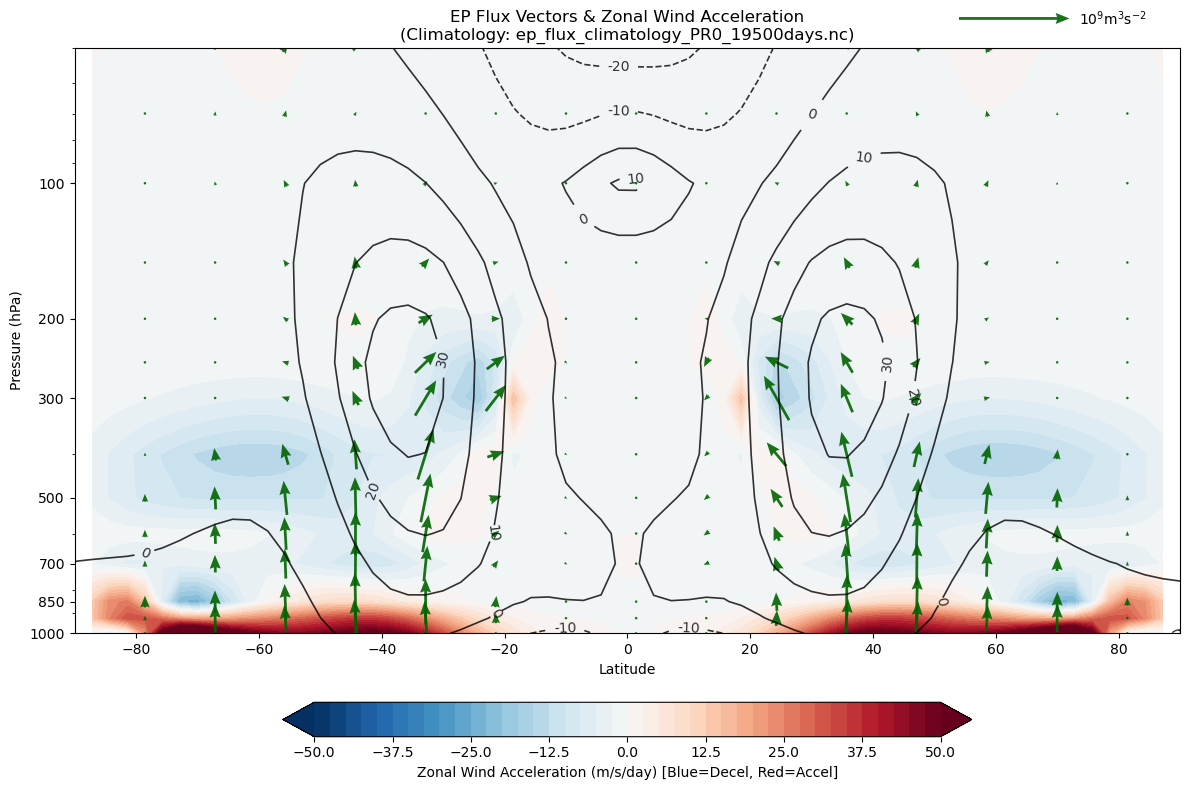

In [56]:
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np

# --- Configuration ---
# Update this to match the file output from the batch script
# FILENAME = "ep_flux_climatology_PR0_19500days.nc"
# FILENAME = f"ep_flux_climatology_PR0_{TOTAL_DAYS}days.nc"
FILENAME = "ep_flux_climatology_PR0_19500days.nc"

def plot_ep_flux_climatology(filename):
    print(f"Reading {filename}...")
    try:
        ds = xr.open_dataset(filename)
    except FileNotFoundError:
        print(f"File '{filename}' not found. Please check the path.")
        return

    # --- 1. Fix Dimensions ---
    # Ensure (plev, lat) order for plotting
    if 'sigma' in ds.coords:
         # Just in case we didn't interpolate, but the calc script does interpolate.
         pass
    
    # Transpose for matplotlib (Y, X)
    ds = ds.transpose('plev', 'lat')
    
    # # --- 2. PHYSICS CHECK: Units are already correct ---
    # # In the batch calculation script:
    # # div_F is calculated as (term_phi + term_z) * 86400
    # # term_phi included the 1/(a*cos_phi) factor.
    # # Therefore, ds.div_F is ALREADY in m/s/day.
    
    # accel = ds.div_F

    # --- 3. PHYSICS CORRECTION: Convert Torque to Acceleration ---
    # The calculated 'div_F' is the divergence of Angular Momentum Flux (Torque).
    # To get Zonal Wind Acceleration (m/s/day), we must divide by the moment arm (a * cos(phi)).
    
    lat_rad = np.deg2rad(ds.lat)
    cos_lat = np.cos(lat_rad)
    
    # Avoid division by zero at poles by masking very small cosines
    cos_lat = cos_lat.where(np.abs(cos_lat) > 1e-2)
    
    # Calculate Acceleration: Units become (m/s/day)
    # The 'div_F' input was already scaled to 'per day' in the calculation script.
    accel = ds.div_F / (a * cos_lat)

    # --- 3. Diagnostics ---
    max_acc = np.nanmax(accel.values)
    min_acc = np.nanmin(accel.values)
    print(f"DIAGNOSTICS:")
    print(f"  Acceleration Max: {max_acc:.4f} m/s/day")
    print(f"  Acceleration Min: {min_acc:.4f} m/s/day")
    print(f"  u_bar Max: {ds.u_bar.max().values:.2f} m/s")

    # --- 4. Vector Scaling ---
    # Fz is typically 100-300x smaller than Fphi. We scale it up for visibility.
    F_Z_SCALE = 200.0 
    F_z_scaled = ds.F_z * F_Z_SCALE

    # --- 5. Plotting Setup ---
    fig, ax = plt.subplots(figsize=(12, 8))

    # A. Contour Filled: Zonal Wind Acceleration
    # For a long-term climatology (19500 days), accelerations are usually 
    # smaller (balancing friction/coriolis) than instantaneous shocks.
    # We reduce the limit from 50 to 10 or 5 m/s/day.
    limit = 50
    levels = np.linspace(-limit, limit, 41) 
    
    cf = ax.contourf(ds.lat, ds.plev, accel, 
                     levels=levels, 
                     cmap='RdBu_r', 
                     extend='both')
    
    cbar = plt.colorbar(cf, ax=ax, orientation='horizontal', pad=0.1, fraction=0.05)
    cbar.set_label('Zonal Wind Acceleration (m/s/day) [Blue=Decel, Red=Accel]')

    # B. Contour Lines: Zonal Mean Wind (u_bar)
    # Shows the Jet Stream structure
    clevs_u = np.arange(-20, 100, 10) # Adjusted range for climatology
    cs = ax.contour(ds.lat, ds.plev, ds.u_bar, 
                    levels=clevs_u, 
                    colors='black', 
                    linewidths=1.2,
                    alpha=0.8)
    ax.clabel(cs, fmt='%d', fontsize=10, inline=True)

    # C. Quiver: EP Flux Vectors
    # Subsample to avoid clutter
    skip_lat = 4 
    skip_lev = 1
    
    lat_sub = ds.lat[::skip_lat]
    lev_sub = ds.plev[::skip_lev]
    F_phi_sub = ds.F_phi[::skip_lev, ::skip_lat]
    F_z_sub = F_z_scaled[::skip_lev, ::skip_lat]

    # Vector Scale: Adjusted for Climatology
    # Climatological fluxes might be slightly different than instantaneous
    vector_scale = 1e10 # Adjust this if arrows are too big/small
    
    Q = ax.quiver(lat_sub, lev_sub, F_phi_sub, F_z_sub,
                  color='darkgreen',
                  alpha=0.9,
                  width=0.0025,
                  headwidth=4,
                  scale=vector_scale, 
                  pivot='mid')

    # Reference Key
    ax.quiverkey(Q, 0.9, 1.05, 1e9, r'$10^9 \mathrm{m}^3 \mathrm{s}^{-2}$', labelpos='E', coordinates='axes')

    # D. Axis Formatting
    ax.set_yscale('log')
    ax.set_ylim(100000, 5000) # 1000 hPa to 50 hPa
    # ax.invert_yaxis() # Log scale usually handles direction, but check output
    
    ax.yaxis.set_major_formatter(ticker.ScalarFormatter())
    ax.set_yticks([100000, 85000, 70000, 50000, 30000, 20000, 10000])
    ax.set_yticklabels(['1000', '850', '700', '500', '300', '200', '100'])
    
    ax.set_title(f'EP Flux Vectors & Zonal Wind Acceleration\n(Climatology: {FILENAME})')
    ax.set_xlabel('Latitude')
    ax.set_ylabel('Pressure (hPa)')
    
    plt.tight_layout()
    plt.show()

# --- Execution ---
if __name__ == "__main__":
    plot_ep_flux_climatology(FILENAME)

Reading ep_flux_climatology_PR50_19500days.nc...
DIAGNOSTICS:
  Acceleration Max: 36.2044 m/s/day
  Acceleration Min: -47.6464 m/s/day
  u_bar Max: 43.92 m/s


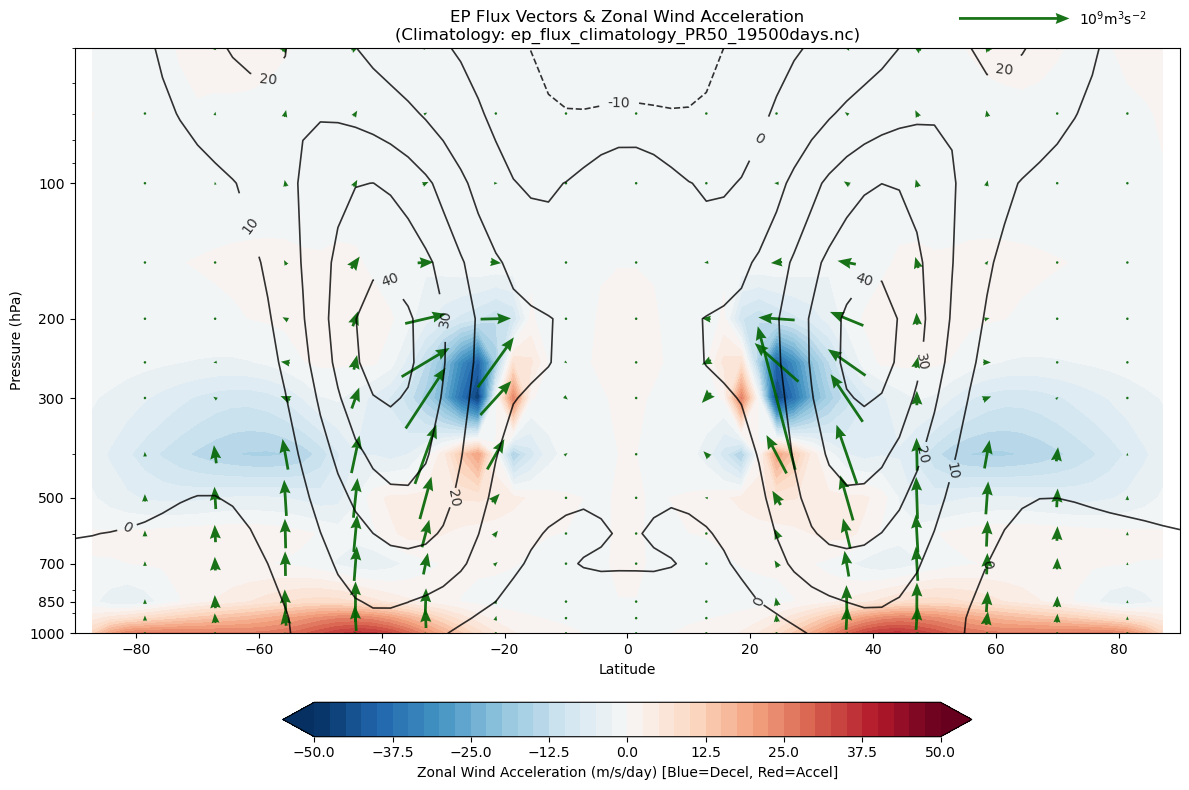

In [57]:
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np

# --- Configuration ---
# Update this to match the file output from the batch script
# FILENAME = "ep_flux_climatology_PR0_19500days.nc"
# FILENAME = f"ep_flux_climatology_PR0_{TOTAL_DAYS}days.nc"
FILENAME = "ep_flux_climatology_PR50_19500days.nc"

def plot_ep_flux_climatology(filename):
    print(f"Reading {filename}...")
    try:
        ds = xr.open_dataset(filename)
    except FileNotFoundError:
        print(f"File '{filename}' not found. Please check the path.")
        return

    # --- 1. Fix Dimensions ---
    # Ensure (plev, lat) order for plotting
    if 'sigma' in ds.coords:
         # Just in case we didn't interpolate, but the calc script does interpolate.
         pass
    
    # Transpose for matplotlib (Y, X)
    ds = ds.transpose('plev', 'lat')
    
    # # --- 2. PHYSICS CHECK: Units are already correct ---
    # # In the batch calculation script:
    # # div_F is calculated as (term_phi + term_z) * 86400
    # # term_phi included the 1/(a*cos_phi) factor.
    # # Therefore, ds.div_F is ALREADY in m/s/day.
    
    # accel = ds.div_F

    # --- 3. PHYSICS CORRECTION: Convert Torque to Acceleration ---
    # The calculated 'div_F' is the divergence of Angular Momentum Flux (Torque).
    # To get Zonal Wind Acceleration (m/s/day), we must divide by the moment arm (a * cos(phi)).
    
    lat_rad = np.deg2rad(ds.lat)
    cos_lat = np.cos(lat_rad)
    
    # Avoid division by zero at poles by masking very small cosines
    cos_lat = cos_lat.where(np.abs(cos_lat) > 1e-2)
    
    # Calculate Acceleration: Units become (m/s/day)
    # The 'div_F' input was already scaled to 'per day' in the calculation script.
    accel = ds.div_F / (a * cos_lat)

    # --- 3. Diagnostics ---
    max_acc = np.nanmax(accel.values)
    min_acc = np.nanmin(accel.values)
    print(f"DIAGNOSTICS:")
    print(f"  Acceleration Max: {max_acc:.4f} m/s/day")
    print(f"  Acceleration Min: {min_acc:.4f} m/s/day")
    print(f"  u_bar Max: {ds.u_bar.max().values:.2f} m/s")

    # --- 4. Vector Scaling ---
    # Fz is typically 100-300x smaller than Fphi. We scale it up for visibility.
    F_Z_SCALE = 200.0 
    F_z_scaled = ds.F_z * F_Z_SCALE

    # --- 5. Plotting Setup ---
    fig, ax = plt.subplots(figsize=(12, 8))

    # A. Contour Filled: Zonal Wind Acceleration
    # For a long-term climatology (19500 days), accelerations are usually 
    # smaller (balancing friction/coriolis) than instantaneous shocks.
    # We reduce the limit from 50 to 10 or 5 m/s/day.
    limit = 50
    levels = np.linspace(-limit, limit, 41) 
    
    cf = ax.contourf(ds.lat, ds.plev, accel, 
                     levels=levels, 
                     cmap='RdBu_r', 
                     extend='both')
    
    cbar = plt.colorbar(cf, ax=ax, orientation='horizontal', pad=0.1, fraction=0.05)
    cbar.set_label('Zonal Wind Acceleration (m/s/day) [Blue=Decel, Red=Accel]')

    # B. Contour Lines: Zonal Mean Wind (u_bar)
    # Shows the Jet Stream structure
    clevs_u = np.arange(-20, 100, 10) # Adjusted range for climatology
    cs = ax.contour(ds.lat, ds.plev, ds.u_bar, 
                    levels=clevs_u, 
                    colors='black', 
                    linewidths=1.2,
                    alpha=0.8)
    ax.clabel(cs, fmt='%d', fontsize=10, inline=True)

    # C. Quiver: EP Flux Vectors
    # Subsample to avoid clutter
    skip_lat = 4 
    skip_lev = 1
    
    lat_sub = ds.lat[::skip_lat]
    lev_sub = ds.plev[::skip_lev]
    F_phi_sub = ds.F_phi[::skip_lev, ::skip_lat]
    F_z_sub = F_z_scaled[::skip_lev, ::skip_lat]

    # Vector Scale: Adjusted for Climatology
    # Climatological fluxes might be slightly different than instantaneous
    vector_scale = 1e10 # Adjust this if arrows are too big/small
    
    Q = ax.quiver(lat_sub, lev_sub, F_phi_sub, F_z_sub,
                  color='darkgreen',
                  alpha=0.9,
                  width=0.0025,
                  headwidth=4,
                  scale=vector_scale, 
                  pivot='mid')

    # Reference Key
    ax.quiverkey(Q, 0.9, 1.05, 1e9, r'$10^9 \mathrm{m}^3 \mathrm{s}^{-2}$', labelpos='E', coordinates='axes')

    # D. Axis Formatting
    ax.set_yscale('log')
    ax.set_ylim(100000, 5000) # 1000 hPa to 50 hPa
    # ax.invert_yaxis() # Log scale usually handles direction, but check output
    
    ax.yaxis.set_major_formatter(ticker.ScalarFormatter())
    ax.set_yticks([100000, 85000, 70000, 50000, 30000, 20000, 10000])
    ax.set_yticklabels(['1000', '850', '700', '500', '300', '200', '100'])
    
    ax.set_title(f'EP Flux Vectors & Zonal Wind Acceleration\n(Climatology: {FILENAME})')
    ax.set_xlabel('Latitude')
    ax.set_ylabel('Pressure (hPa)')
    
    plt.tight_layout()
    plt.show()

# --- Execution ---
if __name__ == "__main__":
    plot_ep_flux_climatology(FILENAME)

# Calculate EP flux with positive and negative time index

In [61]:
# read PC1 positive and negative time index
pr = 0
with h5py.File(f"/data92/PeterChang/back_to_master1220/Moist_Dycore/EPflux/New_PC1_time_idx/PC1_positive_1std_PR{pr}.h5", 'r') as F:
    pc1_pos_idx = F['time_idx_pos'][0]  # (N,) array of integers

with h5py.File(f"/data92/PeterChang/back_to_master1220/Moist_Dycore/EPflux/New_PC1_time_idx/PC1_negative_1std_PR{pr}.h5", 'r') as F:
    pc1_neg_idx = F['time_idx_neg'][0]  # (N,) array of integers


In [62]:
print(pc1_pos_idx.shape, pc1_neg_idx.shape)

(12482,) (13331,)


In [63]:
import h5py
import numpy as np
import xarray as xr
from tqdm import tqdm
from contextlib import ExitStack

# --- Configuration ---
PR = 0
TOTAL_DAYS = 19500      
STEPS_PER_DAY = 4       # 6-hourly data
N_STEPS = TOTAL_DAYS * STEPS_PER_DAY

# Keep batch size reasonable (e.g., 5 days) for memory management
BATCH_DAYS = 5          
BATCH_STEPS = BATCH_DAYS * STEPS_PER_DAY

output_file = f"/data92/PeterChang/back_to_master1220/Moist_Dycore/IdealizeSpetral.jl/exp/HSt42/RA_EPflux/positive/ep_flux_composite_PC1_pos_PR{PR}.nc"

base_dir = f"/data92/PeterChang/Dycore_data/PR{PR}"
file_paths = {
    'u': f"{base_dir}/u/PR{PR}_500_20000day_u_6hourly.h5",
    'v': f"{base_dir}/v/PR{PR}_500_20000day_v_6hourly.h5",
    't': f"{base_dir}/t/PR{PR}_500_20000day_t_6hourly.h5",
    'ps': f"{base_dir}/ps/PR{PR}_500_20000day_ps_6hourly.h5"
}

# Path to the Time Indices
idx_file_path = f"/data92/PeterChang/back_to_master1220/Moist_Dycore/EPflux/New_PC1_time_idx/PC1_positive_1std_PR{PR}.h5"

# --- Shared Coordinates ---
lat = np.linspace(-90, 90, 64)
lon = np.linspace(0, 360, 128, endpoint=False)
sigma = np.linspace(0.05, 1.0, 20) 
target_plevs_pa = np.array([1000, 925, 850, 700, 600, 500, 400, 
                            300, 250, 200, 150, 100, 70, 50]) * 100.0

# --- Worker Function ---
def process_batch(start_idx, end_idx, open_files, relative_indices):
    """
    Reads the full batch (for speed) but filters down to specific relative_indices
    BEFORE doing any heavy interpolation or physics.
    """
    
    # 1. Load Data Slice (Fast Sequential I/O)
    data_arrays = {}
    
    # Create the full time array for this batch, then slice it
    full_batch_time = np.arange(start_idx, end_idx) * 0.25 
    batch_time = full_batch_time[relative_indices]

    for var, f_handle in open_files.items():
        key = list(f_handle.keys())[0]
        # Read the contiguous chunk (faster than fancy indexing on disk)
        data = f_handle[key][start_idx:end_idx]
        
        # Filter immediately in memory
        data = data[relative_indices]
        
        if var == 'ps' and data.ndim == 4:
            data = data[:, 0, :, :]
        data_arrays[var] = data

    ds = xr.Dataset(
        data_vars={
            'u': (('time', 'sigma', 'lat', 'lon'), data_arrays['u']),
            'v': (('time', 'sigma', 'lat', 'lon'), data_arrays['v']),
            't': (('time', 'sigma', 'lat', 'lon'), data_arrays['t']),
            'ps': (('time', 'lat', 'lon'), data_arrays['ps']),
        },
        coords={'time': batch_time, 'sigma': sigma, 'lat': lat, 'lon': lon}
    )

    # 2. Calculation setup
    a = 6.371e6; R = 287.0; cp = 1004.0; kappa = R/cp
    Omega = 7.2921e-5; P0 = 100000.0; H = 7000.0
    
    lat_rad = np.deg2rad(ds.lat)
    cos_lat = np.cos(lat_rad)
    f_cor = 2 * Omega * np.sin(lat_rad)
    
    plev_da = xr.DataArray(target_plevs_pa, dims='plev', coords={'plev': target_plevs_pa})

    # 3. Interpolation Loop (Only runs on the filtered 'positive' steps)
    iso_list = []
    
    for t_idx in range(ds.sizes['time']):
        ds_step = ds.isel(time=t_idx)
        target_sigma_step = plev_da / ds_step.ps
        iso_step = ds_step[['u', 'v', 't']].interp(sigma=target_sigma_step, method='linear')
        iso_list.append(iso_step)

    if not iso_list:
        return None

    # Recombine
    ds_iso = xr.concat(iso_list, dim='time')
    
    # 4. EP Flux Calculations
    ds_iso['theta'] = ds_iso.t * (P0 / plev_da)**kappa

    # Zonal Means
    u_bar = ds_iso.u.mean(dim='lon')
    v_bar = ds_iso.v.mean(dim='lon')
    th_bar = ds_iso.theta.mean(dim='lon')
    
    uv_eddy = ((ds_iso.u - u_bar) * (ds_iso.v - v_bar)).mean(dim='lon')
    vth_eddy = ((ds_iso.v - v_bar) * (ds_iso.theta - th_bar)).mean(dim='lon')

    # Stability
    dth_dp = th_bar.differentiate('plev')
    dth_dz = -(plev_da / H) * dth_dp
    dth_dz = dth_dz.where(np.abs(dth_dz) > 1e-4)

    # Fluxes
    F_phi = -1 * a * cos_lat * uv_eddy
    F_z = a * cos_lat * f_cor * (vth_eddy / dth_dz)

    # Divergence
    F_phi_cos = F_phi * cos_lat
    term_phi = (1.0 / (a * cos_lat)) * F_phi_cos.differentiate('lat') * (180.0 / np.pi)
    
    dFz_dp = F_z.differentiate('plev')
    dFz_dz = -(plev_da / H) * dFz_dp
    term_z = dFz_dz - (F_z / H)
    
    div_F = (term_phi + term_z) * 86400.0

    return xr.Dataset({
        'F_phi': F_phi, 
        'F_z': F_z, 
        'div_F': div_F, 
        'u_bar': u_bar
    })

# --- Main Loop ---
if __name__ == "__main__":
    
    # 1. Load PC1 Positive Indices
    print(f"Loading indices from {idx_file_path}...")
    with h5py.File(idx_file_path, 'r') as F:
        # Handling potential shape differences: (N,) or (1, N)
        raw_idx = F['time_idx_pos'][:]
        pc1_pos_idx = np.sort(raw_idx.ravel())
        
    print(f"Total positive time steps to process: {len(pc1_pos_idx)}")

    accumulated_sum = None
    accumulated_count = None

    with ExitStack() as stack:
        open_files = {
            var: stack.enter_context(h5py.File(path, 'r')) 
            for var, path in file_paths.items()
        }
        print("Files opened. Starting loop...")

        for start_idx in tqdm(range(0, N_STEPS, BATCH_STEPS)):
            end_idx = min(start_idx + BATCH_STEPS, N_STEPS)
            
            # --- INDEX CHECKING ---
            # Create array of global indices for this current batch
            batch_indices_global = np.arange(start_idx, end_idx)
            
            # Find which of these are in our target list
            # isin returns boolean mask same shape as batch_indices_global
            mask = np.isin(batch_indices_global, pc1_pos_idx)
            
            # Optimization: If no target indices in this batch, skip entirely
            if not np.any(mask):
                continue
            
            # Get the relative indices (0 to BATCH_STEPS) to keep
            relative_indices = np.where(mask)[0]
            
            # 2. Process only the relevant slices
            batch_result = process_batch(start_idx, end_idx, open_files, relative_indices)
            
            if batch_result is None: continue

            # 3. Accumulate
            if accumulated_sum is None:
                accumulated_sum = batch_result.sum(dim='time')
                accumulated_count = batch_result.count(dim='time')
            else:
                accumulated_sum += batch_result.sum(dim='time')
                accumulated_count += batch_result.count(dim='time')
            
            # Cleanup
            del batch_result

    # --- Final Calculation ---
    print("Calculating final composite mean...")
    if accumulated_count is not None:
        accumulated_count = accumulated_count.where(accumulated_count > 0)
        result_mean = accumulated_sum / accumulated_count

        print(f"Saving to {output_file}...")
        result_mean.to_netcdf(output_file)
        print("Done!")
    else:
        print("No matching indices found. No file saved.")

--- STARTING TEST RUN ---
Target: Process first 1000 days only.
Loading indices from /data92/PeterChang/back_to_master1220/Moist_Dycore/EPflux/New_PC1_time_idx/PC1_positive_1std_PR0.h5...
Loaded 12482 total positive indices.
First 10 indices: [391 392 393 394 395 396 397 414 415 416]


100%|████████████████████████████████████████████████████████████████████████| 200/200 [00:10<00:00, 18.62it/s]


--- TEST SUMMARY ---
Total time steps scanned: 4000
Total matching 'positive' steps processed: 143

--- RESULTS CHECK ---
u_bar [Mean]: 4.7789
div_F [Min]:  -8.5773e+19
div_F [Max]:  2.0518e+20

Saving test file to /data92/PeterChang/back_to_master1220/Moist_Dycore/IdealizeSpetral.jl/exp/HSt42/RA_EPflux/positive/test_ep_flux_composite_PR0_1000days.nc...
Done!


Reading /data92/PeterChang/back_to_master1220/Moist_Dycore/IdealizeSpetral.jl/exp/HSt42/RA_EPflux/positive/test_ep_flux_composite_PR0_1000days.nc...
DIAGNOSTICS:
  Acceleration Max: 134.0598 m/s/day
  Acceleration Min: -50.6816 m/s/day
  u_bar Max: 39.50 m/s


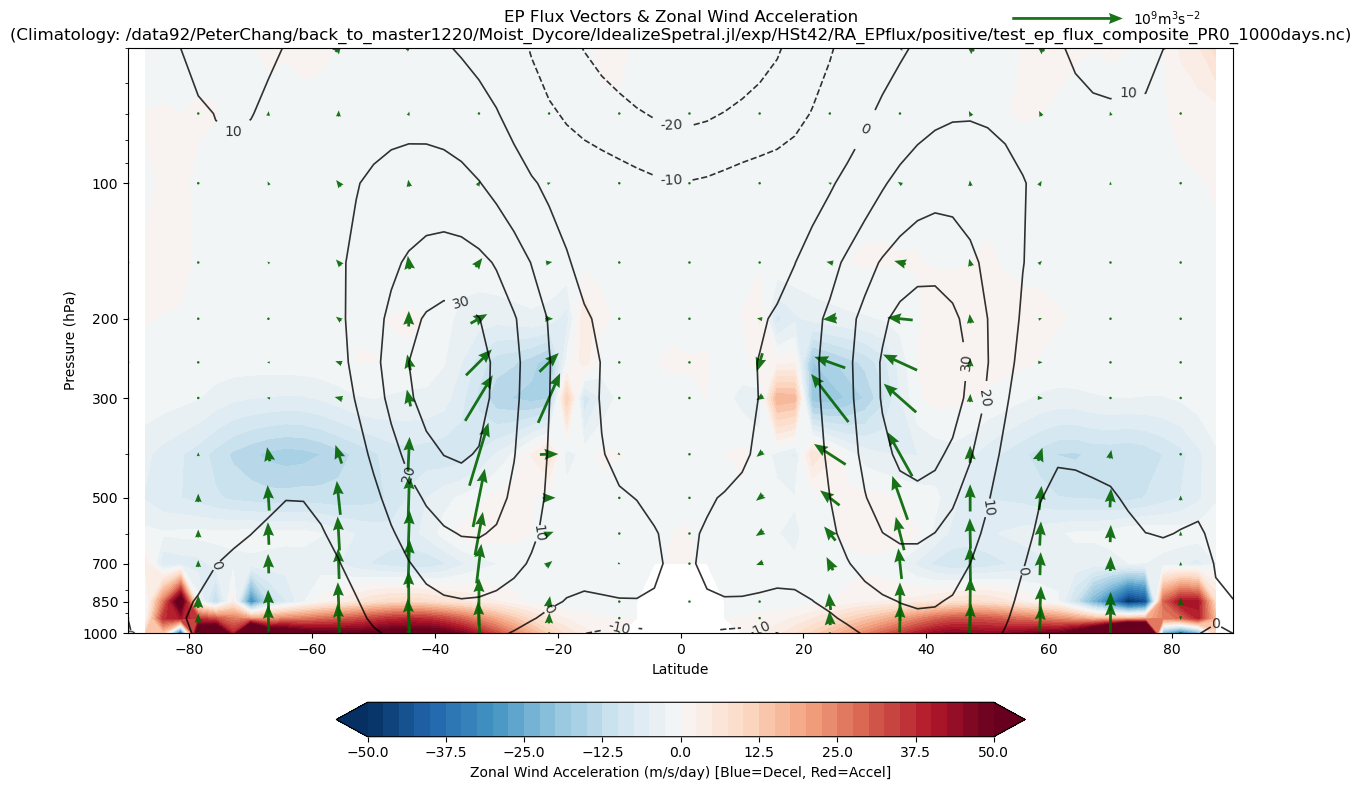

In [64]:
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np

# --- Configuration ---
# Update this to match the file output from the batch script
FILENAME = "/data92/PeterChang/back_to_master1220/Moist_Dycore/IdealizeSpetral.jl/exp/HSt42/RA_EPflux/positive/test_ep_flux_composite_PR0_1000days.nc"

def plot_ep_flux_climatology(filename):
    print(f"Reading {filename}...")
    try:
        ds = xr.open_dataset(filename)
    except FileNotFoundError:
        print(f"File '{filename}' not found. Please check the path.")
        return

    # --- 1. Fix Dimensions ---
    # Ensure (plev, lat) order for plotting
    if 'sigma' in ds.coords:
         # Just in case we didn't interpolate, but the calc script does interpolate.
         pass
    
    # Transpose for matplotlib (Y, X)
    ds = ds.transpose('plev', 'lat')
    
    # # --- 2. PHYSICS CHECK: Units are already correct ---
    # # In the batch calculation script:
    # # div_F is calculated as (term_phi + term_z) * 86400
    # # term_phi included the 1/(a*cos_phi) factor.
    # # Therefore, ds.div_F is ALREADY in m/s/day.
    
    # accel = ds.div_F

    # --- 3. PHYSICS CORRECTION: Convert Torque to Acceleration ---
    # The calculated 'div_F' is the divergence of Angular Momentum Flux (Torque).
    # To get Zonal Wind Acceleration (m/s/day), we must divide by the moment arm (a * cos(phi)).
    
    lat_rad = np.deg2rad(ds.lat)
    cos_lat = np.cos(lat_rad)
    
    # Avoid division by zero at poles by masking very small cosines
    cos_lat = cos_lat.where(np.abs(cos_lat) > 1e-2)
    
    # Calculate Acceleration: Units become (m/s/day)
    # The 'div_F' input was already scaled to 'per day' in the calculation script.
    accel = ds.div_F / (a * cos_lat)

    # --- 3. Diagnostics ---
    max_acc = np.nanmax(accel.values)
    min_acc = np.nanmin(accel.values)
    print(f"DIAGNOSTICS:")
    print(f"  Acceleration Max: {max_acc:.4f} m/s/day")
    print(f"  Acceleration Min: {min_acc:.4f} m/s/day")
    print(f"  u_bar Max: {ds.u_bar.max().values:.2f} m/s")

    # --- 4. Vector Scaling ---
    # Fz is typically 100-300x smaller than Fphi. We scale it up for visibility.
    F_Z_SCALE = 200.0 
    F_z_scaled = ds.F_z * F_Z_SCALE

    # --- 5. Plotting Setup ---
    fig, ax = plt.subplots(figsize=(12, 8))

    # A. Contour Filled: Zonal Wind Acceleration
    # For a long-term climatology (19500 days), accelerations are usually 
    # smaller (balancing friction/coriolis) than instantaneous shocks.
    # We reduce the limit from 50 to 10 or 5 m/s/day.
    limit = 50
    levels = np.linspace(-limit, limit, 41) 
    
    cf = ax.contourf(ds.lat, ds.plev, accel, 
                     levels=levels, 
                     cmap='RdBu_r', 
                     extend='both')
    
    cbar = plt.colorbar(cf, ax=ax, orientation='horizontal', pad=0.1, fraction=0.05)
    cbar.set_label('Zonal Wind Acceleration (m/s/day) [Blue=Decel, Red=Accel]')

    # B. Contour Lines: Zonal Mean Wind (u_bar)
    # Shows the Jet Stream structure
    clevs_u = np.arange(-20, 100, 10) # Adjusted range for climatology
    cs = ax.contour(ds.lat, ds.plev, ds.u_bar, 
                    levels=clevs_u, 
                    colors='black', 
                    linewidths=1.2,
                    alpha=0.8)
    ax.clabel(cs, fmt='%d', fontsize=10, inline=True)

    # C. Quiver: EP Flux Vectors
    # Subsample to avoid clutter
    skip_lat = 4 
    skip_lev = 1
    
    lat_sub = ds.lat[::skip_lat]
    lev_sub = ds.plev[::skip_lev]
    F_phi_sub = ds.F_phi[::skip_lev, ::skip_lat]
    F_z_sub = F_z_scaled[::skip_lev, ::skip_lat]

    # Vector Scale: Adjusted for Climatology
    # Climatological fluxes might be slightly different than instantaneous
    vector_scale = 1e10 # Adjust this if arrows are too big/small
    
    Q = ax.quiver(lat_sub, lev_sub, F_phi_sub, F_z_sub,
                  color='darkgreen',
                  alpha=0.9,
                  width=0.0025,
                  headwidth=4,
                  scale=vector_scale, 
                  pivot='mid')

    # Reference Key
    ax.quiverkey(Q, 0.9, 1.05, 1e9, r'$10^9 \mathrm{m}^3 \mathrm{s}^{-2}$', labelpos='E', coordinates='axes')

    # D. Axis Formatting
    ax.set_yscale('log')
    ax.set_ylim(100000, 5000) # 1000 hPa to 50 hPa
    # ax.invert_yaxis() # Log scale usually handles direction, but check output
    
    ax.yaxis.set_major_formatter(ticker.ScalarFormatter())
    ax.set_yticks([100000, 85000, 70000, 50000, 30000, 20000, 10000])
    ax.set_yticklabels(['1000', '850', '700', '500', '300', '200', '100'])
    
    ax.set_title(f'EP Flux Vectors & Zonal Wind Acceleration\n(Climatology: {FILENAME})')
    ax.set_xlabel('Latitude')
    ax.set_ylabel('Pressure (hPa)')
    
    plt.tight_layout()
    plt.show()

# --- Execution ---
if __name__ == "__main__":
    plot_ep_flux_climatology(FILENAME)

## negative time idx

In [ ]:
import h5py
import numpy as np
import xarray as xr
from tqdm import tqdm
from contextlib import ExitStack

# --- Configuration ---
PR = 0
TOTAL_DAYS = 19500      
STEPS_PER_DAY = 4       # 6-hourly data
N_STEPS = TOTAL_DAYS * STEPS_PER_DAY

# Keep batch size reasonable (e.g., 5 days) for memory management
BATCH_DAYS = 5          
BATCH_STEPS = BATCH_DAYS * STEPS_PER_DAY

# UPDATED: Output file path for NEGATIVE phase
output_file = f"/data92/PeterChang/back_to_master1220/Moist_Dycore/IdealizeSpetral.jl/exp/HSt42/RA_EPflux/negative/ep_flux_composite_PC1_neg_PR{PR}.nc"

base_dir = f"/data92/PeterChang/Dycore_data/PR{PR}"
file_paths = {
    'u': f"{base_dir}/u/PR{PR}_500_20000day_u_6hourly.h5",
    'v': f"{base_dir}/v/PR{PR}_500_20000day_v_6hourly.h5",
    't': f"{base_dir}/t/PR{PR}_500_20000day_t_6hourly.h5",
    'ps': f"{base_dir}/ps/PR{PR}_500_20000day_ps_6hourly.h5"
}

# UPDATED: Path to the Negative Time Indices
idx_file_path = f"/data92/PeterChang/back_to_master1220/Moist_Dycore/EPflux/New_PC1_time_idx/PC1_negative_1std_PR{PR}.h5"

# --- Shared Coordinates ---
lat = np.linspace(-90, 90, 64)
lon = np.linspace(0, 360, 128, endpoint=False)
sigma = np.linspace(0.05, 1.0, 20) 
target_plevs_pa = np.array([1000, 925, 850, 700, 600, 500, 400, 
                            300, 250, 200, 150, 100, 70, 50]) * 100.0

# --- Worker Function ---
def process_batch(start_idx, end_idx, open_files, relative_indices):
    """
    Reads the full batch (for speed) but filters down to specific relative_indices
    BEFORE doing any heavy interpolation or physics.
    """
    
    # 1. Load Data Slice (Fast Sequential I/O)
    data_arrays = {}
    
    # Create the full time array for this batch, then slice it
    full_batch_time = np.arange(start_idx, end_idx) * 0.25 
    batch_time = full_batch_time[relative_indices]

    for var, f_handle in open_files.items():
        key = list(f_handle.keys())[0]
        # Read the contiguous chunk (faster than fancy indexing on disk)
        data = f_handle[key][start_idx:end_idx]
        
        # Filter immediately in memory
        data = data[relative_indices]
        
        if var == 'ps' and data.ndim == 4:
            data = data[:, 0, :, :]
        data_arrays[var] = data

    ds = xr.Dataset(
        data_vars={
            'u': (('time', 'sigma', 'lat', 'lon'), data_arrays['u']),
            'v': (('time', 'sigma', 'lat', 'lon'), data_arrays['v']),
            't': (('time', 'sigma', 'lat', 'lon'), data_arrays['t']),
            'ps': (('time', 'lat', 'lon'), data_arrays['ps']),
        },
        coords={'time': batch_time, 'sigma': sigma, 'lat': lat, 'lon': lon}
    )

    # 2. Calculation setup
    a = 6.371e6; R = 287.0; cp = 1004.0; kappa = R/cp
    Omega = 7.2921e-5; P0 = 100000.0; H = 7000.0
    
    lat_rad = np.deg2rad(ds.lat)
    cos_lat = np.cos(lat_rad)
    f_cor = 2 * Omega * np.sin(lat_rad)
    
    plev_da = xr.DataArray(target_plevs_pa, dims='plev', coords={'plev': target_plevs_pa})

    # 3. Interpolation Loop (Only runs on the filtered 'positive' steps)
    iso_list = []
    
    for t_idx in range(ds.sizes['time']):
        ds_step = ds.isel(time=t_idx)
        target_sigma_step = plev_da / ds_step.ps
        iso_step = ds_step[['u', 'v', 't']].interp(sigma=target_sigma_step, method='linear')
        iso_list.append(iso_step)

    if not iso_list:
        return None

    # Recombine
    ds_iso = xr.concat(iso_list, dim='time')
    
    # 4. EP Flux Calculations
    ds_iso['theta'] = ds_iso.t * (P0 / plev_da)**kappa

    # Zonal Means
    u_bar = ds_iso.u.mean(dim='lon')
    v_bar = ds_iso.v.mean(dim='lon')
    th_bar = ds_iso.theta.mean(dim='lon')
    
    uv_eddy = ((ds_iso.u - u_bar) * (ds_iso.v - v_bar)).mean(dim='lon')
    vth_eddy = ((ds_iso.v - v_bar) * (ds_iso.theta - th_bar)).mean(dim='lon')

    # Stability
    dth_dp = th_bar.differentiate('plev')
    dth_dz = -(plev_da / H) * dth_dp
    dth_dz = dth_dz.where(np.abs(dth_dz) > 1e-4)

    # Fluxes
    F_phi = -1 * a * cos_lat * uv_eddy
    F_z = a * cos_lat * f_cor * (vth_eddy / dth_dz)

    # Divergence
    F_phi_cos = F_phi * cos_lat
    term_phi = (1.0 / (a * cos_lat)) * F_phi_cos.differentiate('lat') * (180.0 / np.pi)
    
    dFz_dp = F_z.differentiate('plev')
    dFz_dz = -(plev_da / H) * dFz_dp
    term_z = dFz_dz - (F_z / H)
    
    div_F = (term_phi + term_z) * 86400.0

    return xr.Dataset({
        'F_phi': F_phi, 
        'F_z': F_z, 
        'div_F': div_F, 
        'u_bar': u_bar
    })

# --- Main Loop ---
if __name__ == "__main__":
    
    # 1. Load PC1 NEGATIVE Indices
    print(f"Loading indices from {idx_file_path}...")
    with h5py.File(idx_file_path, 'r') as F:
        # UPDATED: Reading 'time_idx_neg' instead of 'pos'
        raw_idx = F['time_idx_neg'][:]
        pc1_neg_idx = np.sort(raw_idx.ravel())
        
    print(f"Total negative time steps to process: {len(pc1_neg_idx)}")

    accumulated_sum = None
    accumulated_count = None

    with ExitStack() as stack:
        open_files = {
            var: stack.enter_context(h5py.File(path, 'r')) 
            for var, path in file_paths.items()
        }
        print("Files opened. Starting loop...")

        for start_idx in tqdm(range(0, N_STEPS, BATCH_STEPS)):
            end_idx = min(start_idx + BATCH_STEPS, N_STEPS)
            
            # --- INDEX CHECKING ---
            batch_indices_global = np.arange(start_idx, end_idx)
            
            # Find which of these are in our target list
            mask = np.isin(batch_indices_global, pc1_neg_idx)
            
            if not np.any(mask):
                continue
            
            relative_indices = np.where(mask)[0]
            
            # 2. Process
            batch_result = process_batch(start_idx, end_idx, open_files, relative_indices)
            
            if batch_result is None: continue

            # 3. Accumulate
            if accumulated_sum is None:
                accumulated_sum = batch_result.sum(dim='time')
                accumulated_count = batch_result.count(dim='time')
            else:
                accumulated_sum += batch_result.sum(dim='time')
                accumulated_count += batch_result.count(dim='time')
            
            del batch_result

    # --- Final Calculation ---
    print("Calculating final composite mean...")
    if accumulated_count is not None:
        accumulated_count = accumulated_count.where(accumulated_count > 0)
        result_mean = accumulated_sum / accumulated_count

        print(f"Saving to {output_file}...")
        result_mean.to_netcdf(output_file)
        print("Done!")
    else:
        print("No matching indices found. No file saved.")